# K Means for Iris Dataset

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd

In [3]:
iris = load_iris()

In [4]:
X = iris.data
y = iris.target

<Axes: >

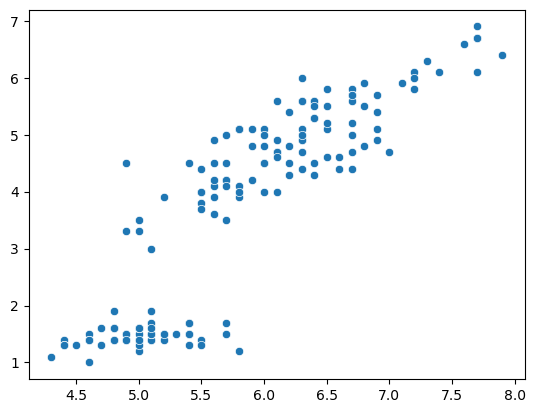

In [5]:
sns.scatterplot(x=X[:, 0], y=X[:, 2])

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [19]:
# Optional - Dimensionality reduction using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

In [20]:
# Elbow method

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

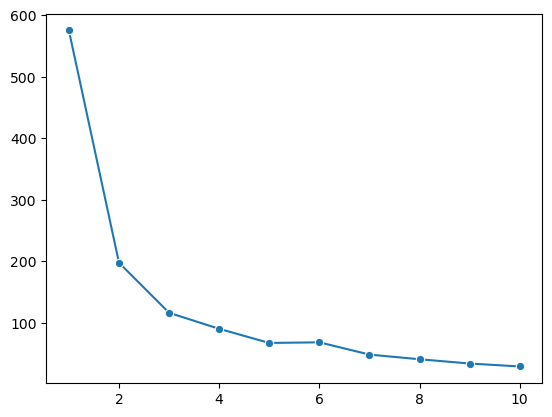

In [21]:
sns.lineplot(x=range(1,11), y=wcss, marker='o')

<Axes: >

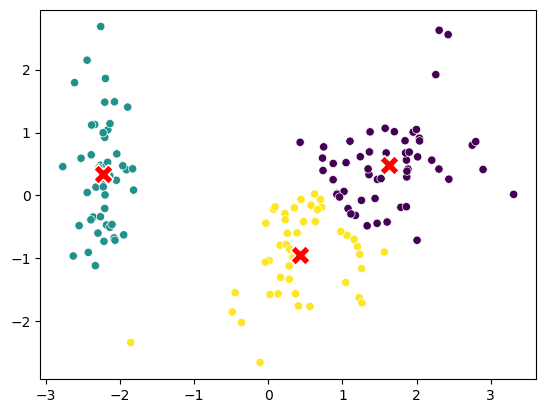

In [33]:
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], marker='X', c='red', s=200)